<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Confidence Intervals: Theory, Simulation & Coverage Analysis
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Applied Econometrics with Python<br>
        <strong>Topic:</strong> Confidence Interval<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Date:</strong> Summer 2025<br>    
        <strong>Learning Objectives:</strong>
        <ul style="margin:5px 0; padding-left:20px;">
            <li>Understand the theoretical foundation and proper interpretation of confidence intervals</li>
            <li>Implement confidence interval calculations using OLS regression in Python</li>
            <li>Validate coverage properties through Monte Carlo simulation with 2,000 samples</li>
            <li>Analyze the relationship between confidence level, interval width, and precision</li>
        </ul>
    </div>
</div>

In [1]:
# =================================================== #
#          Environment Setup
# =================================================== #
from IPython.display import display, Math, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

%reload_ext watermark
%watermark -iv -v -ud

Last updated: 2025-06-24

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.1.0

scipy      : 1.15.3
IPython    : 9.1.0
matplotlib : 3.10.0
statsmodels: 0.14.4
seaborn    : 0.13.2
pandas     : 2.2.3
numpy      : 2.3.0



In [2]:
# =============================== #
#    True Population Parameters
# =============================== #

# Set random seed for reproducibility
np.random.seed(42)

print("1. DEFINING THE TRUE POPULATION MODEL")
print("-" * 40)

# Define the TRUE population parameters (these are FIXED constants)
TRUE_BETA_0 = 2.5      # True intercept
TRUE_BETA_1 = 0.08     # True return to education (8%)
TRUE_BETA_2 = 0.04     # True return to experience
TRUE_BETA_3 = -0.15    # True gender wage gap (-15%)
TRUE_SIGMA = 0.35      # True error standard deviation

display(Markdown("**True Population Model:**"))
display(Markdown(
    f"$$\\ln(\\text{{wage}}) = {TRUE_BETA_0} + {TRUE_BETA_1}\\cdot\\text{{education}} + {TRUE_BETA_2}\\cdot\\text{{experience}} + {TRUE_BETA_3}\\cdot\\text{{female}} + u$$"
))

1. DEFINING THE TRUE POPULATION MODEL
----------------------------------------


**True Population Model:**

$$\ln(\text{wage}) = 2.5 + 0.08\cdot\text{education} + 0.04\cdot\text{experience} + -0.15\cdot\text{female} + u$$

In [3]:
# Display model distribution and constants
display(Markdown(
    f"$$u \\sim \\mathcal{{N}}(0,\\ {TRUE_SIGMA}^2)$$"
))

display(Markdown("**THESE PARAMETERS ARE FIXED CONSTANTS IN THE POPULATION**"))

display(Markdown(f"- $\\beta_0$ = {TRUE_BETA_0} *(intercept)*"))
display(Markdown(f"- $\\beta_1$ = {TRUE_BETA_1} *(return to education)*"))
display(Markdown(f"- $\\beta_2$ = {TRUE_BETA_2} *(return to experience)*"))
display(Markdown(f"- $\\beta_3$ = {TRUE_BETA_3} *(gender wage gap)*"))
display(Markdown(f"- $\\sigma$ = {TRUE_SIGMA}"))

$$u \sim \mathcal{N}(0,\ 0.35^2)$$

**THESE PARAMETERS ARE FIXED CONSTANTS IN THE POPULATION**

- $\beta_0$ = 2.5 *(intercept)*

- $\beta_1$ = 0.08 *(return to education)*

- $\beta_2$ = 0.04 *(return to experience)*

- $\beta_3$ = -0.15 *(gender wage gap)*

- $\sigma$ = 0.35

In [4]:
# =============================== #
#    Population Data Generation
# =============================== #

print(f"\n2. CREATING THE ENTIRE POPULATION")
print("-" * 40)

# Create a large population
POPULATION_SIZE = 500_000
print(f"Creating population of {POPULATION_SIZE:,} workers...")

# Generate population characteristics
np.random.seed(42)
education_pop = np.random.normal(12, 3, POPULATION_SIZE)      # Years of education
experience_pop = np.random.exponential(8, POPULATION_SIZE)    # Years of experience
female_pop = np.random.binomial(1, 0.5, POPULATION_SIZE)      # Gender (50% female)

# Generate wages using the TRUE model
error_pop = np.random.normal(0, TRUE_SIGMA, POPULATION_SIZE)
log_wage_pop = (TRUE_BETA_0 + 
                TRUE_BETA_1 * education_pop + 
                TRUE_BETA_2 * experience_pop + 
                TRUE_BETA_3 * female_pop +
                error_pop)

# Create population DataFrame
population = pd.DataFrame({
    'log_wage': log_wage_pop,
    'education': education_pop,
    'experience': experience_pop,
    'female': female_pop
})

display(Markdown(" **Population created successfully!**"))
display(Markdown("### Population Statistics"))

display(Markdown(
    f"- **Education**: Mean = {education_pop.mean():.2f}, Std = {education_pop.std():.2f}  \n"
    f"- **Experience**: Mean = {experience_pop.mean():.2f}, Std = {experience_pop.std():.2f}  \n"
    f"- **Female Proportion**: {female_pop.mean():.2f}  \n"
    f"- **Log(Wage)**: Mean = {log_wage_pop.mean():.2f}, Std = {log_wage_pop.std():.2f}"
))


2. CREATING THE ENTIRE POPULATION
----------------------------------------
Creating population of 500,000 workers...


 **Population created successfully!**

### Population Statistics

- **Education**: Mean = 12.00, Std = 3.00  
- **Experience**: Mean = 8.01, Std = 8.02  
- **Female Proportion**: 0.50  
- **Log(Wage)**: Mean = 3.71, Std = 0.54

In [5]:
# =============================== #
#   Confidence Interval Function
# =============================== #

def calculate_confidence_intervals(population_data, sample_size=800, confidence_level=0.95):
    """
    Draw a random sample and calculate confidence intervals for all coefficients.
    
    This function simulates what researchers do:
    1. Take a random sample from the population
    2. Run OLS regression
    3. Calculate confidence intervals for each coefficient
    
    Parameters:
    -----------
    population_data : DataFrame
        The entire population data
    sample_size : int
        Size of the sample to draw
    confidence_level : float
        Confidence level (e.g., 0.95 for 95% CI)
        
    Returns:
    --------
    dict : Dictionary containing coefficient estimates and confidence intervals
    """
    
    # Randomly sample from population
    sample_indices = np.random.choice(len(population_data), 
                                    size=sample_size, 
                                    replace=False)
    sample = population_data.iloc[sample_indices].copy()
    
    # Estimate OLS regression
    model = smf.ols('log_wage ~ education + experience + female', data=sample).fit()
    
    # Calculate confidence intervals
    alpha = 1 - confidence_level
    conf_int = model.conf_int(alpha=alpha)
    
    # Extract results
    results = {
        'sample_size': sample_size,
        'confidence_level': confidence_level,
        # Coefficient estimates
        'beta_0': model.params['Intercept'],
        'beta_1': model.params['education'],
        'beta_2': model.params['experience'], 
        'beta_3': model.params['female'],
        # Standard errors
        'se_0': model.bse['Intercept'],
        'se_1': model.bse['education'],
        'se_2': model.bse['experience'],
        'se_3': model.bse['female'],
        # Confidence intervals
        'ci_0_lower': conf_int.loc['Intercept', 0],
        'ci_0_upper': conf_int.loc['Intercept', 1],
        'ci_1_lower': conf_int.loc['education', 0],
        'ci_1_upper': conf_int.loc['education', 1],
        'ci_2_lower': conf_int.loc['experience', 0],
        'ci_2_upper': conf_int.loc['experience', 1],
        'ci_3_lower': conf_int.loc['female', 0],
        'ci_3_upper': conf_int.loc['female', 1],
        # CI widths
        'ci_1_width': conf_int.loc['education', 1] - conf_int.loc['education', 0],
        'ci_2_width': conf_int.loc['experience', 1] - conf_int.loc['experience', 0],
        'ci_3_width': conf_int.loc['female', 1] - conf_int.loc['female', 0],
        # Other statistics
        'r_squared': model.rsquared,
        'sigma_hat': np.sqrt(model.mse_resid)
    }
    
    return results

In [6]:
print(f"\n3. DEMONSTRATION: ONE SAMPLE CONFIDENCE INTERVALS")
print("-" * 50)

# Show what happens with one sample
one_sample_result = calculate_confidence_intervals(population, sample_size=800)
# Display sample results and confidence intervals
display(Markdown("### Results from One Random Sample of 800 Workers"))
display(Markdown("#### Coefficient Estimates and 95% Confidence Intervals"))

display(Markdown(
    f"- $\\beta_0$: {one_sample_result['beta_0']:.4f} "
    f"[{one_sample_result['ci_0_lower']:.4f}, {one_sample_result['ci_0_upper']:.4f}]"
))

display(Markdown(
    f"- $\\beta_1$: {one_sample_result['beta_1']:.4f} "
    f"[{one_sample_result['ci_1_lower']:.4f}, {one_sample_result['ci_1_upper']:.4f}] "
    f"(True = {TRUE_BETA_1})"
))

display(Markdown(
    f"- $\\beta_2$: {one_sample_result['beta_2']:.4f} "
    f"[{one_sample_result['ci_2_lower']:.4f}, {one_sample_result['ci_2_upper']:.4f}] "
    f"(True = {TRUE_BETA_2})"
))

display(Markdown(
    f"- $\\beta_3$: {one_sample_result['beta_3']:.4f} "
    f"[{one_sample_result['ci_3_lower']:.4f}, {one_sample_result['ci_3_upper']:.4f}] "
    f"(True = {TRUE_BETA_3})"
))

# Check inclusion of true values
contains_1 = one_sample_result['ci_1_lower'] <= TRUE_BETA_1 <= one_sample_result['ci_1_upper']
contains_2 = one_sample_result['ci_2_lower'] <= TRUE_BETA_2 <= one_sample_result['ci_2_upper']
contains_3 = one_sample_result['ci_3_lower'] <= TRUE_BETA_3 <= one_sample_result['ci_3_upper']

# Display inclusion checks
display(Markdown("#### Do the Confidence Intervals Contain the True Values?"))
display(Markdown(f"- **Education CI contains true $\\beta_1$**: {'✓ YES' if contains_1 else '✗ NO'}"))
display(Markdown(f"- **Experience CI contains true $\\beta_2$**: {'✓ YES' if contains_2 else '✗ NO'}"))
display(Markdown(f"- **Female CI contains true $\\beta_3$**: {'✓ YES' if contains_3 else '✗ NO'}"))


3. DEMONSTRATION: ONE SAMPLE CONFIDENCE INTERVALS
--------------------------------------------------


### Results from One Random Sample of 800 Workers

#### Coefficient Estimates and 95% Confidence Intervals

- $\beta_0$: 2.5551 [2.4511, 2.6591]

- $\beta_1$: 0.0766 [0.0685, 0.0847] (True = 0.08)

...

- $\beta_3$: -0.1300 [-0.1788, -0.0813] (True = -0.15)

#### Do the Confidence Intervals Contain the True Values?

- **Education CI contains true $\beta_1$**: ✓ YES

- **Experience CI contains true $\beta_2$**: ✓ YES

- **Female CI contains true $\beta_3$**: ✓ YES

In [7]:
# =============================== #
#    Monte Carlo Simulation
# =============================== #

print(f"\n4. MONTE CARLO SIMULATION: MANY CONFIDENCE INTERVALS")
print("-" * 54)

# Parameters for simulation
NUM_SAMPLES = 2000               # Number of different samples to draw
SAMPLE_SIZE = 800                # Size of each sample
CONFIDENCE_LEVEL = 0.95

print(f"Drawing {NUM_SAMPLES:,} different samples of size {SAMPLE_SIZE:,} each...")
print(f"Calculating {CONFIDENCE_LEVEL:.0%} confidence intervals for each sample...")
print("This may take a moment...")

# Store results from each sample
ci_results = []

# Simulate many different confidence intervals
for i in range(NUM_SAMPLES):
    if (i + 1) % 500 == 0:
        print(f"  Completed {i + 1:,} samples...")
    
    # Each iteration draws a DIFFERENT random sample and calculates CIs
    sample_result = calculate_confidence_intervals(population, SAMPLE_SIZE, CONFIDENCE_LEVEL)
    ci_results.append(sample_result)

# Convert to DataFrame for analysis
ci_simulation = pd.DataFrame(ci_results)

print(f"\nSimulation completed! We now have {NUM_SAMPLES:,} different confidence intervals.")


4. MONTE CARLO SIMULATION: MANY CONFIDENCE INTERVALS
------------------------------------------------------
Drawing 2,000 different samples of size 800 each...
Calculating 95% confidence intervals for each sample...
This may take a moment...
  Completed 500 samples...
  Completed 1,000 samples...
  Completed 1,500 samples...
  Completed 2,000 samples...

Simulation completed! We now have 2,000 different confidence intervals.


In [8]:
# ========================================================== #
#             Coverage Probability Analysis
# ========================================================== #

print(f"\n5. CONFIDENCE INTERVAL COVERAGE ANALYSIS")
print("-" * 43)

# Check coverage for each parameter
true_values = [TRUE_BETA_1, TRUE_BETA_2, TRUE_BETA_3]
param_names = ['Education (β₁)', 'Experience (β₂)', 'Female (β₃)']
ci_lower_cols = ['ci_1_lower', 'ci_2_lower', 'ci_3_lower']
ci_upper_cols = ['ci_1_upper', 'ci_2_upper', 'ci_3_upper']

print(f"Coverage Analysis for {CONFIDENCE_LEVEL:.0%} Confidence Intervals:")
print(f"Expected coverage rate: {CONFIDENCE_LEVEL:.3f}")
print()

coverage_results = {}
for i, (param, true_val) in enumerate(zip(param_names, true_values)):
    # Check how many CIs contain the true value
    lower_col = ci_lower_cols[i]
    upper_col = ci_upper_cols[i]
    
    contains_true = ((ci_simulation[lower_col] <= true_val) & 
                    (true_val <= ci_simulation[upper_col]))
    
    coverage_rate = contains_true.mean()
    num_containing = contains_true.sum()
    
    coverage_results[param] = {
        'coverage_rate': coverage_rate,
        'num_containing': num_containing,
        'true_value': true_val
    }
    
    print(f"{param:20s}:")
    print(f"  Coverage rate: {coverage_rate:.3f} ({num_containing:,}/{NUM_SAMPLES:,})")
    print(f"  Expected: {CONFIDENCE_LEVEL:.3f}")
    print(f"  Difference: {abs(coverage_rate - CONFIDENCE_LEVEL):.3f}")
    
    if abs(coverage_rate - CONFIDENCE_LEVEL) <= 0.02:
        print(f"  Result: ✓ EXCELLENT coverage")
    elif abs(coverage_rate - CONFIDENCE_LEVEL) <= 0.05:
        print(f"  Result: ✓ GOOD coverage")
    else:
        print(f"  Result: ⚠ Coverage deviates from expected")
    print()


5. CONFIDENCE INTERVAL COVERAGE ANALYSIS
-------------------------------------------
Coverage Analysis for 95% Confidence Intervals:
Expected coverage rate: 0.950

Education (β₁)      :
  Coverage rate: 0.953 (1,906/2,000)
  Expected: 0.950
  Difference: 0.003
  Result: ✓ EXCELLENT coverage

Experience (β₂)     :
  Coverage rate: 0.948 (1,896/2,000)
  Expected: 0.950
  Difference: 0.002
  Result: ✓ EXCELLENT coverage

Female (β₃)         :
  Coverage rate: 0.956 (1,912/2,000)
  Expected: 0.950
  Difference: 0.006
  Result: ✓ EXCELLENT coverage



In [9]:
# ========================================================= #
#             Confidence Interval Properties
# ========================================================= #

print(f"\n6. CONFIDENCE INTERVAL PROPERTIES")
print("-" * 35)

# Analyze CI widths
print("Average Confidence Interval Widths:")
avg_width_1 = ci_simulation['ci_1_width'].mean()
avg_width_2 = ci_simulation['ci_2_width'].mean()  
avg_width_3 = ci_simulation['ci_3_width'].mean()

print(f"  Education (β₁): {avg_width_1:.6f}")
print(f"  Experience (β₂): {avg_width_2:.6f}")
print(f"  Female (β₃): {avg_width_3:.6f}")


6. CONFIDENCE INTERVAL PROPERTIES
-----------------------------------
Average Confidence Interval Widths:
  Education (β₁): 0.016232
  Experience (β₂): 0.006084
  Female (β₃): 0.097356


In [10]:
# Standard error analysis
print(f"\nAverage Standard Errors:")
avg_se_1 = ci_simulation['se_1'].mean()
avg_se_2 = ci_simulation['se_2'].mean()
avg_se_3 = ci_simulation['se_3'].mean()

print(f"  Education (β₁): {avg_se_1:.6f}")
print(f"  Experience (β₂): {avg_se_2:.6f}")
print(f"  Female (β₃): {avg_se_3:.6f}")


Average Standard Errors:
  Education (β₁): 0.004135
  Experience (β₂): 0.001550
  Female (β₃): 0.024799


In [11]:
# Relationship between CI width and SE
critical_value = stats.t.ppf(1 - (1-CONFIDENCE_LEVEL)/2, SAMPLE_SIZE - 4)  # 4 parameters
theoretical_width_1 = 2 * critical_value * avg_se_1
theoretical_width_2 = 2 * critical_value * avg_se_2
theoretical_width_3 = 2 * critical_value * avg_se_3

print(f"\nCI Width vs Theoretical (2 × t × SE):")
print(f"  Education: Actual = {avg_width_1:.6f}, Theoretical = {theoretical_width_1:.6f}")
print(f"  Experience: Actual = {avg_width_2:.6f}, Theoretical = {theoretical_width_2:.6f}")
print(f"  Female: Actual = {avg_width_3:.6f}, Theoretical = {theoretical_width_3:.6f}")


CI Width vs Theoretical (2 × t × SE):
  Education: Actual = 0.016232, Theoretical = 0.016232
  Experience: Actual = 0.006084, Theoretical = 0.006084
  Female: Actual = 0.097356, Theoretical = 0.097356



7. VISUALIZING CONFIDENCE INTERVALS
-------------------------------------


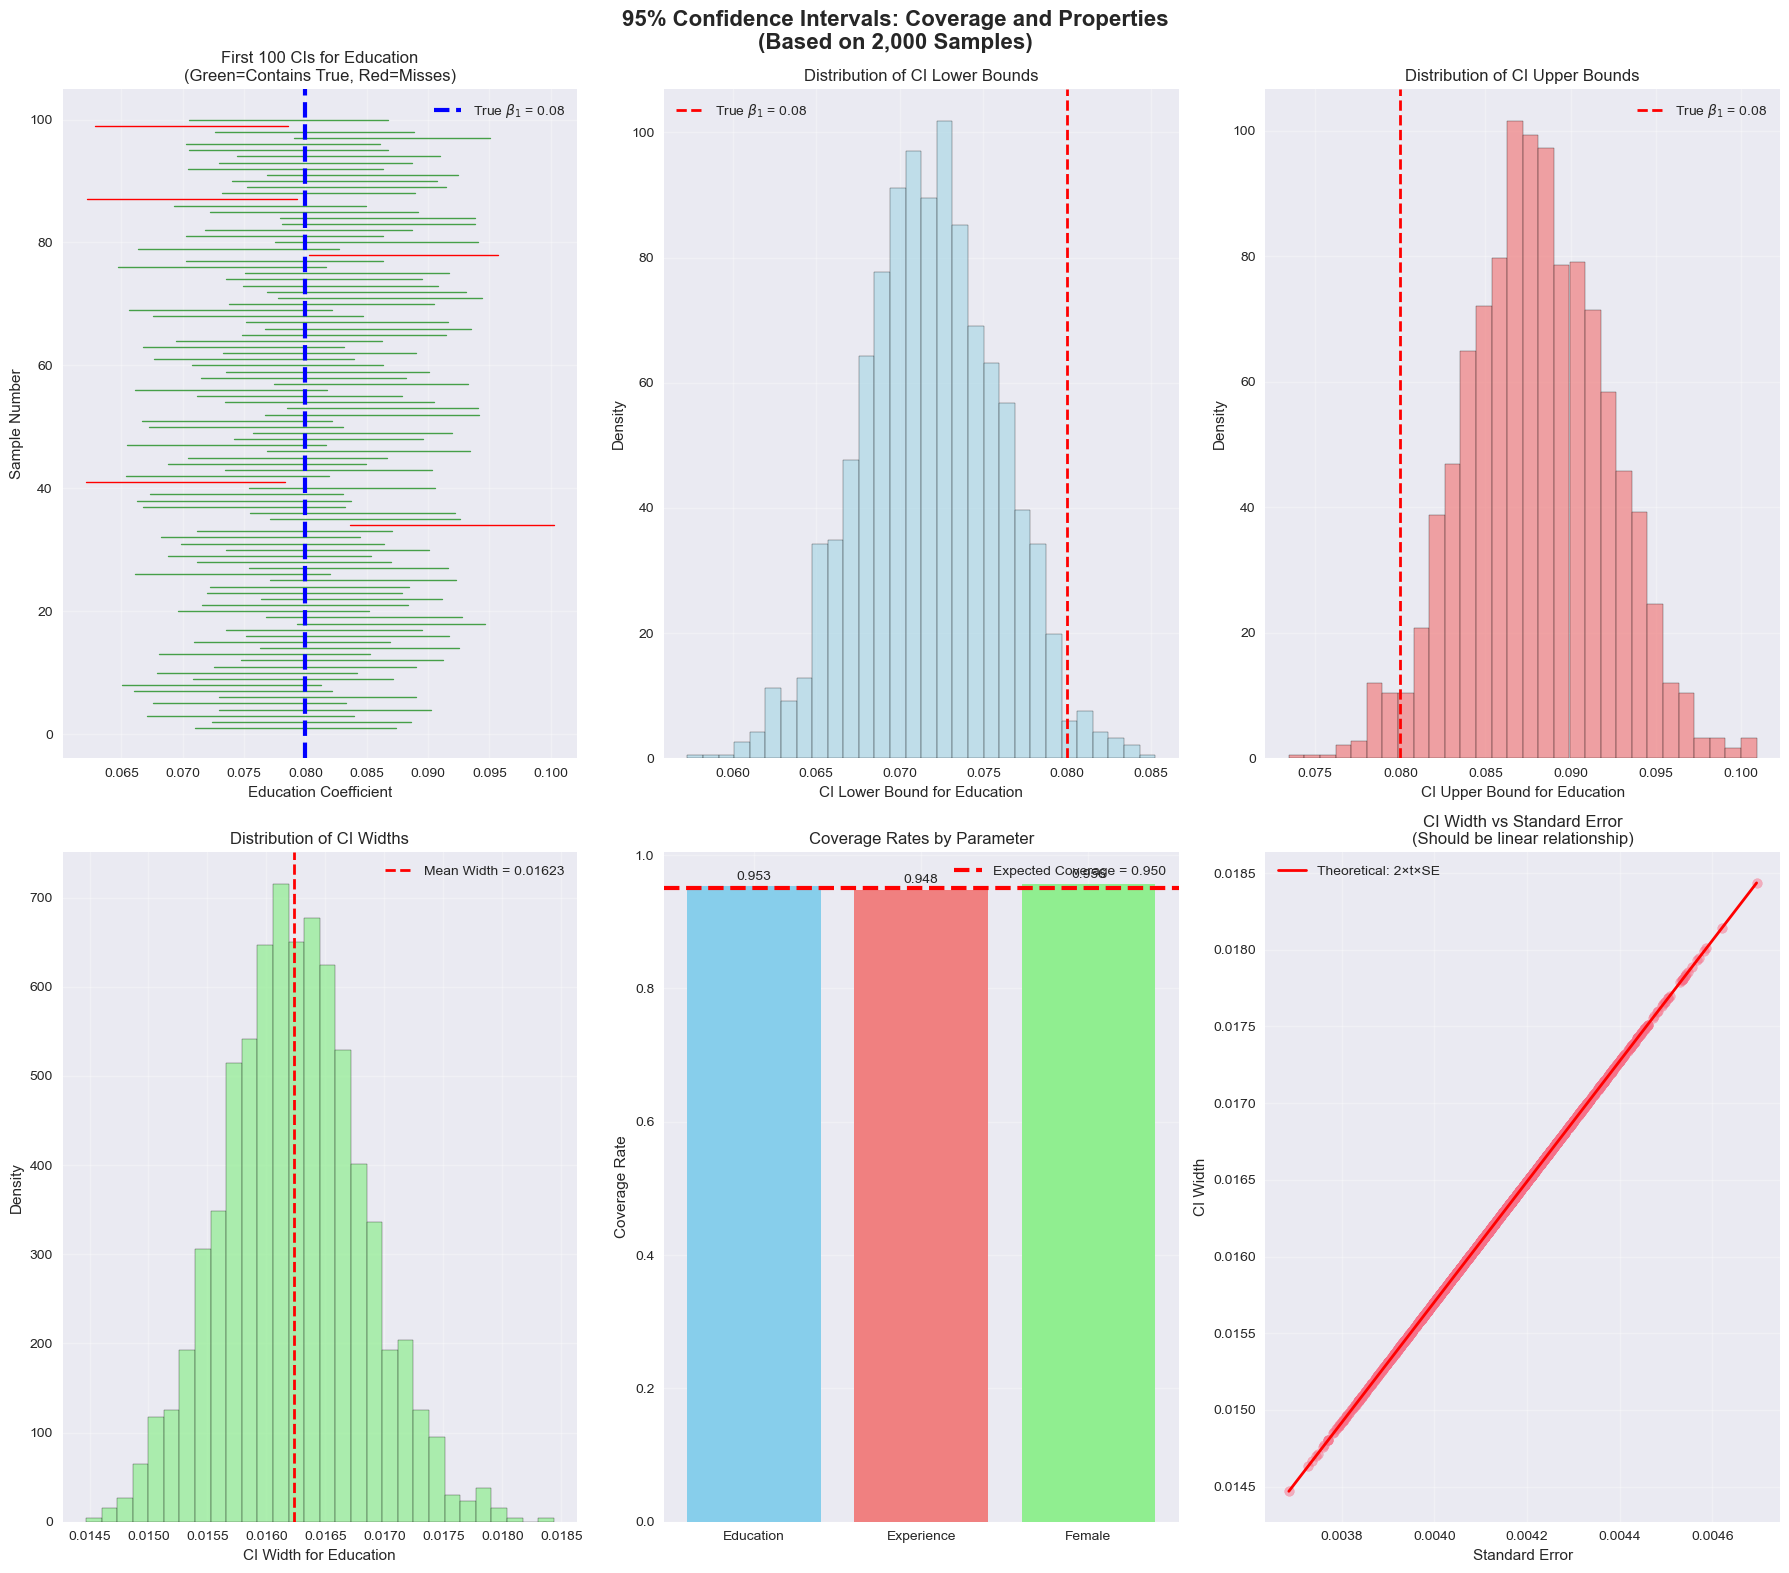

In [12]:
# ========================================================= #
#                   Visualization
# ========================================================= #

print(f"\n7. VISUALIZING CONFIDENCE INTERVALS")
print("-" * 37)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 16))
fig.suptitle(f'{CONFIDENCE_LEVEL:.0%} Confidence Intervals: Coverage and Properties\n'
             f'(Based on {NUM_SAMPLES:,} Samples)', fontsize=16, fontweight='bold')

# Plot 1: CI Coverage for Education
sample_subset = min(100, NUM_SAMPLES)           # Show first 100 CIs
y_positions = range(1, sample_subset + 1)

for i in range(sample_subset):
    ci_lower = ci_simulation.iloc[i]['ci_1_lower']
    ci_upper = ci_simulation.iloc[i]['ci_1_upper']
    contains = ci_lower <= TRUE_BETA_1 <= ci_upper
    
    color = 'green' if contains else 'red'
    alpha = 0.7 if contains else 1.0
    
    axes[0,0].plot([ci_lower, ci_upper], [i+1, i+1], color=color, alpha=alpha, linewidth=1)

axes[0,0].axvline(TRUE_BETA_1, color='blue', linewidth=3, linestyle='--', 
                 label=rf'True $\beta_1$ = {TRUE_BETA_1}')

axes[0,0].set_xlabel('Education Coefficient')
axes[0,0].set_ylabel('Sample Number')
axes[0,0].set_title(f'First {sample_subset} CIs for Education\n(Green=Contains True, Red=Misses)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Distribution of CI Lower Bounds
axes[0,1].hist(ci_simulation['ci_1_lower'], bins=30, density=True, alpha=0.7, 
               color='lightblue', edgecolor='black')
axes[0,1].axvline(TRUE_BETA_1, color='red', linewidth=2, linestyle='--', 
                 label=rf'True $\beta_1$ = {TRUE_BETA_1}')

axes[0,1].set_xlabel('CI Lower Bound for Education')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Distribution of CI Lower Bounds')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Distribution of CI Upper Bounds  
axes[0,2].hist(ci_simulation['ci_1_upper'], bins=30, density=True, alpha=0.7,
               color='lightcoral', edgecolor='black')
axes[0,2].axvline(TRUE_BETA_1, color='red', linewidth=2, linestyle='--',
                 label=rf'True $\beta_1$ = {TRUE_BETA_1}')

axes[0,2].set_xlabel('CI Upper Bound for Education')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Distribution of CI Upper Bounds')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: CI Width Distribution
axes[1,0].hist(ci_simulation['ci_1_width'], bins=30, density=True, alpha=0.7,
               color='lightgreen', edgecolor='black')
axes[1,0].axvline(avg_width_1, color='red', linewidth=2, linestyle='--',
                 label=f'Mean Width = {avg_width_1:.5f}')

axes[1,0].set_xlabel('CI Width for Education')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Distribution of CI Widths')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Coverage Rate by Parameter
param_short = ['Education', 'Experience', 'Female']
coverage_rates = [coverage_results[param]['coverage_rate'] for param in param_names]

bars = axes[1,1].bar(param_short, coverage_rates, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1,1].axhline(CONFIDENCE_LEVEL, color='red', linewidth=3, linestyle='--',
                 label=f'Expected Coverage = {CONFIDENCE_LEVEL:.3f}')

axes[1,1].set_ylabel('Coverage Rate')
axes[1,1].set_title('Coverage Rates by Parameter')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, rate in zip(bars, coverage_rates):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                  f'{rate:.3f}', ha='center', va='bottom')

# Plot 6: Relationship between SE and CI Width
axes[1,2].scatter(ci_simulation['se_1'], ci_simulation['ci_1_width'], alpha=0.5)
axes[1,2].set_xlabel('Standard Error')
axes[1,2].set_ylabel('CI Width')
axes[1,2].set_title('CI Width vs Standard Error\n(Should be linear relationship)')
axes[1,2].grid(True, alpha=0.3)

# Add theoretical line
se_range = np.linspace(ci_simulation['se_1'].min(), ci_simulation['se_1'].max(), 100)
theoretical_widths = 2 * critical_value * se_range
axes[1,2].plot(se_range, theoretical_widths, 'r-', linewidth=2, 
              label='Theoretical: 2×t×SE')
axes[1,2].legend()

plt.tight_layout()
plt.show()